# **Practical Q1: KNN**

### Import Libraries

In [5]:
# Improting needed libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42



---


## Part (a) Load Dataset
### Install & Download Dataset from Kaggle (kagglehub)

In [6]:
!pip -q install kagglehub
import kagglehub

DATASET_SLUG = "rakeshrau/social-network-ads"  # Kaggle dataset slug
dataset_path = kagglehub.dataset_download(DATASET_SLUG)

print("Downloaded to:", dataset_path)

100%|██████████| 3.27k/3.27k [00:00<00:00, 5.96MB/s]

Extracting files...
Downloaded to: /root/.cache/kagglehub/datasets/rakeshrau/social-network-ads/versions/1


### Load CSV File

In [7]:
import os

csv_path = os.path.join(dataset_path, "Social_Network_Ads.csv")
df = pd.read_csv(csv_path)

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Select Features & Target (As Required)

In [8]:
X = df[["Age", "EstimatedSalary"]].copy()
y = df["Purchased"].copy()

X.head(), y.head()

(   Age  EstimatedSalary
 0   19            19000
 1   35            20000
 2   26            43000
 3   27            57000
 4   19            76000,
 0    0
 1    0
 2    0
 3    0
 4    0
 Name: Purchased, dtype: int64)

### Train/Test Split (70/30, Stratified)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain class ratio:\n", y_train.value_counts(normalize=True))
print("\nTest  class ratio:\n", y_test.value_counts(normalize=True))

Train: (280, 2)  Test: (120, 2)

Train class ratio:
 Purchased
0    0.642857
1    0.357143
Name: proportion, dtype: float64

Test  class ratio:
 Purchased
0    0.641667
1    0.358333
Name: proportion, dtype: float64


### Standard Scaling (Fit on Train Only)

In [10]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train
X_test_sc  = scaler.transform(X_test)        # transform test



---


# Part B

### 5-Fold Cross-Validation to Find Best K


In [11]:
k_values = range(1, 26)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_mean_acc = []
cv_std_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring="accuracy")
    cv_mean_acc.append(scores.mean())
    cv_std_acc.append(scores.std())

best_idx = int(np.argmax(cv_mean_acc))
best_k = list(k_values)[best_idx]

print("Best K =", best_k)
print("Best CV Accuracy =", cv_mean_acc[best_idx])
print("CV Std (for best K) =", cv_std_acc[best_idx])

Best K = 11
Best CV Accuracy = 0.9035714285714287
CV Std (for best K) = 0.008748177652797035


### Plot K vs Mean CV Accuracy

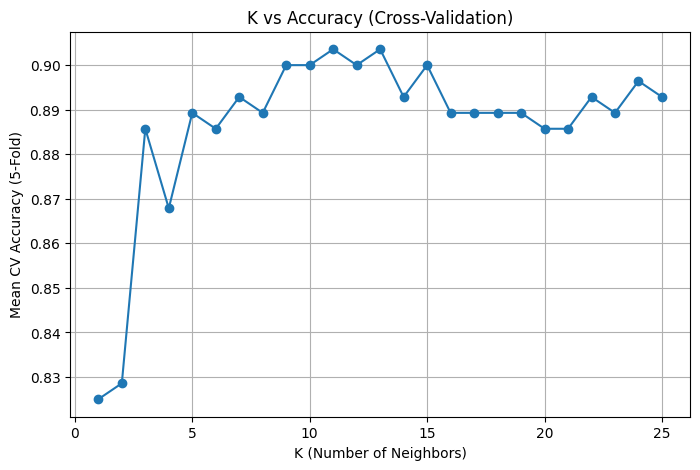

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), cv_mean_acc, marker="o")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Mean CV Accuracy (5-Fold)")
plt.title("K vs Accuracy (Cross-Validation)")
plt.grid(True)
plt.show()



---

# Part C

### Train Final KNN Model with Best K

In [13]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_sc, y_train)

KNeighborsClassifier(n_neighbors=11)

### Test Evaluation (Accuracy + Confusion Matrix)

Test Accuracy = 0.9166666666666666
Confusion Matrix:
 [[72  5]
 [ 5 38]]


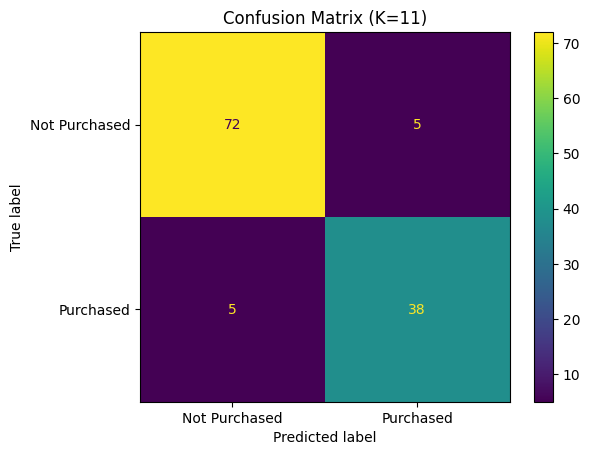

In [14]:
y_pred = final_knn.predict(X_test_sc)

test_acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy =", test_acc)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Purchased", "Purchased"])
disp.plot(values_format="d")
plt.title(f"Confusion Matrix (K={best_k})")
plt.show()



---

# Part D

### 2D Decision Boundary

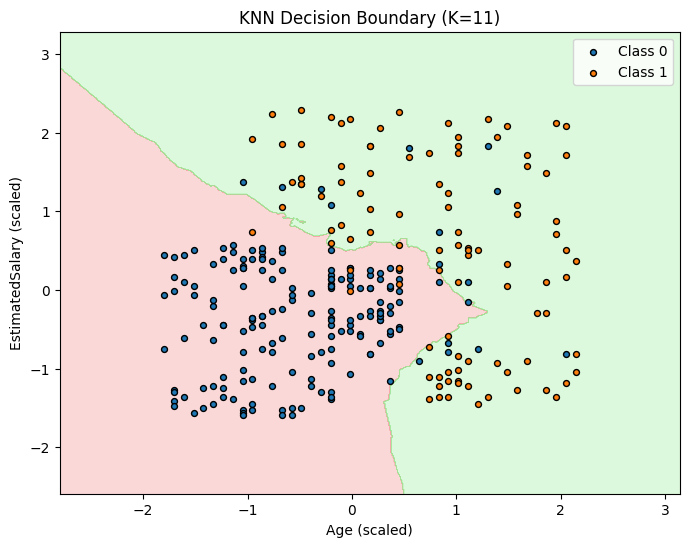

In [15]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train_sc, y_train.values

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
    np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01)
)

plt.figure(figsize=(8, 6))
plt.contourf(
    X1, X2,
    final_knn.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(X1.shape),
    alpha=0.30,
    cmap=ListedColormap(("lightcoral", "lightgreen"))
)

for label in np.unique(y_set):
    plt.scatter(
        X_set[y_set == label, 0],
        X_set[y_set == label, 1],
        edgecolor="k",
        s=18,
        label=f"Class {label}"
    )

plt.title(f"KNN Decision Boundary (K={best_k})")
plt.xlabel("Age (scaled)")
plt.ylabel("EstimatedSalary (scaled)")
plt.legend()
plt.show()